In [1]:
import uuid
from core.logger import app_logger
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from models.schemas import (EducationalMetadata, 
                            ExtractedKnowledge, 
                            TeacherKnowledgePackage,
                            TeachingPlan)
from pipelines.phase1_extraction.extractor import knowledge_extractor
from pipelines.phase2_generation.planner import teaching_planner

from pipelines.phase1_extraction.chunker import document_chunker
from infrastructure.vector_store import vector_store

from core.exceptions import (ExtractionError, 
                            TeachingPlanError)
from langgraph.checkpoint.postgres import PostgresSaver

class PipelineState(TypedDict):
    job_id : str
    raw_text: str
    metadata: EducationalMetadata | None
    knowledge_base: ExtractedKnowledge | None
    teaching_plan: TeachingPlan | None
    validation_errors: list[str]
    current_stage: str

def educational_classification_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    
    app_logger.info(
        "Starting Educational Classification", 
        extra={"extra_info": {"job_id": job_id, "stage": 2}}
    )
    try:
        result: EducationalMetadata = knowledge_extractor.extract_metadata(
            raw_markdown=state["raw_text"],
            job_id=job_id
        )
        return {
            "metadata": result,
            "current_stage": "Stage 2 Complete"
        }
    except Exception as e:
        app_logger.error(
            f"Classification failed: {str(e)}", 
            extra={"extra_info": {"job_id": job_id}}
        )
        raise ExtractionError(message="Stage 2 Failed", details={"job_id": job_id})

def knowledge_extraction_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    
    app_logger.info(
        "Starting Knowledge Extraction", 
        extra={"extra_info": {"job_id": job_id, "stage": 3}}
    )
    try:
        result: ExtractedKnowledge = knowledge_extractor.extract_knowledge(
            metadata_json=state["metadata"],
            raw_markdown=state["raw_text"],
            job_id=job_id
        )
        return {
            "knowledge_base": result,
            "current_stage": "Stage 3 Complete"
        }
    except Exception as e:
        app_logger.error(
            f"Extraction failed: {str(e)}", 
            extra={"extra_info": {"job_id": job_id}}
        )
        raise ExtractionError(message="Stage 3 Failed", details={"job_id": job_id})


def vectorization_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    
    app_logger.info(
        "Starting Document Vectorization", 
        extra={"extra_info": {"job_id": job_id, "stage": 3.5}}
    )
    try:
        chunks = document_chunker.chunk_markdown(state["raw_text"])
        vector_store.ingest_chunks(job_id=job_id, chunks=chunks)
        
        return {
            "current_stage": "Stage 3.5 Complete"
        }
    except Exception as e:
        app_logger.error(
            f"Vectorization failed: {str(e)}", 
            extra={"extra_info": {"job_id": job_id}}
        )
        raise ExtractionError(message="Stage 3.5 Failed", details={"job_id": job_id})


def teaching_planner_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    
    app_logger.info(
        "Starting Teaching Planning", 
        extra={"extra_info": {"job_id": job_id, "stage": 4}}
    )
    try:
        result: TeachingPlan = teaching_planner.planner(
            metadata_json=state["metadata"],
            extracted_knowledge=state["knowledge_base"],
            job_id=job_id
        )
        return {
            "teaching_plan": result,
            "current_stage": "Stage 4 Complete"
        }
    except Exception as e:
        app_logger.error(
            f"Planning failed: {str(e)}", 
            extra={"extra_info": {"job_id": job_id}}
        )
        raise TeachingPlanError(message="Stage 4 Failed", details={"job_id": job_id})


def route_validation(state: PipelineState) -> str:
    if state.get("validation_errors") and len(state["validation_errors"]) > 0:
        app_logger.warning("Validation failed, routing back for correction.")
        return "retry_generation"
    return "proceed_to_publish"

workflow = StateGraph(PipelineState)

workflow.add_node("classify", educational_classification_node)
workflow.add_node("extract", knowledge_extraction_node)
workflow.add_node("vectorize", vectorization_node)
workflow.add_node("plan", teaching_planner_node)

workflow.add_edge(START, "classify")
workflow.add_edge(START, "vectorize")
workflow.add_edge("classify", "extract")

workflow.add_edge("extract", "plan")
workflow.add_edge("vectorize", "plan")
workflow.add_edge("plan", END)
# workflow.add_edge("vectorize", END)



[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


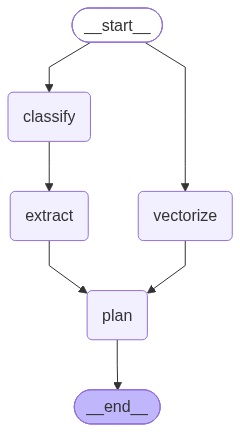

In [3]:
workflow.compile()

In [2]:
from infrastructure.llm_gateway import llm_gateway
from pipelines.phase1_extraction.extractor import knowledge_extractor

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
from llama_index.core import SimpleDirectoryReader

documents = SimpleDirectoryReader(input_files=[r"../data/63d00cdb-f5fb-4d86-9a8e-4cea460455f1.md"]).load_data()

print(f"Loaded {len(documents)} documents.")
print(documents[0].text[:200])

Loaded 1 documents.
# CHAPTER 10
# The Human Eye and the Colourful World
Rainbow over mountains
QR code 1064CH11

You have studied in the previous chapter about refraction of light by lenses. You also studied the na


In [4]:
documents[0].to_dict().keys()

dict_keys(['id_', 'embedding', 'metadata', 'excluded_embed_metadata_keys', 'excluded_llm_metadata_keys', 'relationships', 'metadata_template', 'metadata_separator', 'text_resource', 'image_resource', 'audio_resource', 'video_resource', 'text_template', 'class_name', 'text'])

In [5]:
documents[0].text

"# CHAPTER 10\r\n# The Human Eye and the Colourful World\r\nRainbow over mountains\r\nQR code 1064CH11\r\n\r\nYou have studied in the previous chapter about refraction of light by lenses. You also studied the nature, position and relative size of images formed by lenses. How can these ideas help us in the study of the human eye? The human eye uses light and enables us to see objects around us. It has a lens in its structure. What is the function of the lens in a human eye? How do the lenses used in spectacles correct defects of vision? Let us consider these questions in this chapter.\r\n\r\nWe have learnt in the previous chapter about light and some of its properties. In this chapter, we shall use these ideas to study some of the optical phenomena in nature. We shall also discuss about rainbow formation, splitting of white light and blue colour of the sky.\r\n\r\n## 10.1 THE HUMAN EYE\r\n\r\nThe human eye is one of the most valuable and sensitive sense organs. It enables us to see the 

In [6]:
res = knowledge_extractor.extract_metadata(raw_markdown=documents[0].text)

2026-08-01 11:32:48,936 | INFO     | TeacherAI | Starting Stage 2: Extracting Educational Metadata
2026-08-01 11:32:48,957 | INFO     | TeacherAI | Sending request to LLM Gateway


In [10]:
res

EducationalMetadata(subject='Biology', grade='8th Grade', difficulty='Intermediate', topic='The Human Eye and Vision', chapter='Chapter 10', category='STEM', language='English')

In [ ]:
import uuid
from core.logger import app_logger
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from models.schemas import EducationalMetadata, ExtractedKnowledge, TeacherKnowledgePackage
from pipelines.phase1_extraction.extractor import knowledge_extractor

# logger = logging.getLogger(__name__)

class PipelineState(TypedDict):
    job_id : str
    raw_text: str
    metadata: EducationalMetadata | None
    knowledge_base: ExtractedKnowledge | None
    validation_errors: list[str]
    current_stage: str

def educational_classification_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    
    app_logger.info(
        "Starting Educational Classification", 
        extra={"extra_info": {"job_id": job_id, "stage": 2}}
    )
    try:
        result: EducationalMetadata = knowledge_extractor.extract_metadata()
        
        return {
            "metadata": result,
            "current_stage": "Stage 2 Complete"
        }
    except Exception as e:
        app_logger.error(
            f"Classification failed: {str(e)}", 
            extra={"extra_info": {"job_id": job_id}}
        )
        raise ExtractionError(message="Stage 2 Failed", details={"job_id": job_id})


def route_validation(state: PipelineState) -> str:
    if state.get("validation_errors") and len(state["validation_errors"]) > 0:
        logger.warning("Validation failed, routing back for correction.")
        return "retry_generation"
    return "proceed_to_publish"

def build_tkp_pipeline():
    # workflow
    workflow = StateGraph(PipelineState)
    
    # Nodes
    workflow.add_node("classify", educational_classification_node)
    
    # Edges
    workflow.add_edge(START, "classify")
    workflow.add_edge("classify", END)
    
    return workflow.compile()

def trigger_pipeline(text: str):
    new_job_id = str(uuid.uuid4())
    initial_state = PipelineState(
        job_id=new_job_id,
        raw_text=text,
        metadata=None,
        knowledge_base=None,
        validation_errors=[],
        current_stage="Initialized"
    )
    
    wkflow = build_tkp_pipeline()
    # wkflow.invoke(PipelineState)
    
wrkflow = trigger_pipeline('something')

In [7]:
wrkflow

In [11]:
from langchain_community.tools.ddg_search.tool import DuckDuckGoSearchRun

In [ ]:
ddg = DuckDuckGoSearchRun()

could not parse an IP from hosts file (":1:!")
could not parse an IP from hosts file (":1:!")
could not parse an IP from hosts file (":1:!")
could not parse an IP from hosts file (":1:!")
could not parse an IP from hosts file (":1:!")
could not parse an IP from hosts file (":1:!")


"Graham's number is an immense number that arose as an upper bound on the answer of a problem in the mathematical field of Ramsey theory. What Love Is: The Letters of 1, 2, & 3 John is a seven-session Bible study book written by Kelly Minter and published by Lifeway Press on November 1, 2014. As part of The Living Room Series, the 192-page guide is designed for small-group use and emp… 11:09. Algebra Basics: What Are Polynomials? MAGNETISM for Kids What are Magnets? Science for Kids. Smile and Learn - English. 320K views • 3 years ago. 7:17. 11/3 is.What is a Digital Linear Tape drive? What is the simple interest on a principal of 4200 invested at an interest rate of 8 percent for 3.5 years? What is one third of three quarters of one hundred? What Numbers that are easy to compute with mentally are called? :3 is an emoticon used to represent a Coy Smile. This page explains how :3 is used in texting or on apps like TikTok or Instagram."

In [13]:
res = ddg.invoke("what is class, grade, category, topic, difficuly of the capter The Human Eye and the Colourful World")

could not parse an IP from hosts file (":1:!")
could not parse an IP from hosts file (":1:!")
could not parse an IP from hosts file (":1:!")


In [16]:
from rich import print as p

In [18]:
p(res)

class-10. the human eye and the colourful world. 0 votes. 1 answer. Eye is the only organ to visualise the 
colourful world around us. This is possible due to accommodation of eye lens. Total classes on Filo by this tutor -
2,693. Teaches : Mathematics, English, Social Studies (SST). CHAPTER - 11 THE HUMAN EYE AND THE COLOURFUL WORLD 
Class Subject Name of Students School :- X :- Science :- :- Atmospheric refraction refers to the bending of light 
rays as they pass through the Earth's atmosphere. Human Eye Diagram Class 10. The Human Eye And The Colourful 
World. Hindi Diagram With Eye Movements.Description. While we're on topic about the definition of colours varying 
across cultures. Thanks Kieran! scipsy: The Eye (by Zachary Veach). The eye loses its power of accommodation at old
age.The splitting of white light into its component colours is called dispersion.Scattering of light causes the 
blue colour of sky and the reddening of the Sun at sunrise and sunset.